import libs

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from keras.utils import to_categorical
from keras.datasets import mnist

In [7]:
def get_strategy():
    # Detect hardware and configure parallel compute
    try:
        # Try to detect TPU
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
        tf.config.experimental_connect_to_cluster(resolver)
        tf.tpu.experimental.initialize_tpu_system(resolver)
        strategy = tf.distribute.TPUStrategy(resolver)
        print("TPU detected. Using TPU for parallel computation.")
    except ValueError:
        # If no TPU is found, check for GPU
        if tf.config.list_physical_devices('GPU'):
            print("No TPU detected. GPU detected. Using GPU for parallel computation.")
            strategy = tf.distribute.MirroredStrategy()
        else:
            # If no GPU is found, fall back to CPU
            print("No TPU or GPU detected. Using CPU for parallel computation.")
            strategy = tf.distribute.MultiWorkerMirroredStrategy()
    return strategy
strategy = get_strategy()

No TPU or GPU detected. Using CPU for parallel computation.
INFO:tensorflow:Using MirroredStrategy with devices ('/device:CPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/device:CPU:0',)


INFO:tensorflow:Single-worker MultiWorkerMirroredStrategy with local_devices = ('/device:CPU:0',), communication = CommunicationImplementation.AUTO


INFO:tensorflow:Single-worker MultiWorkerMirroredStrategy with local_devices = ('/device:CPU:0',), communication = CommunicationImplementation.AUTO


Enable GPU parallel processing

In [8]:
strategy = tf.distribute.MirroredStrategy()
print(f'Number of devices: {strategy.num_replicas_in_sync}')

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


Number of devices: 1


load dataset

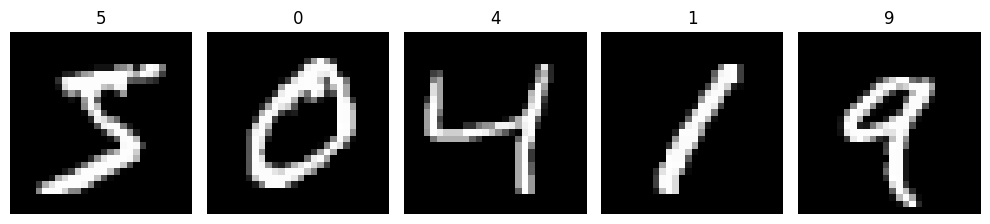

In [9]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

Normalize, reshape to 28*28*1, one hot labeling the 10 classes

In [10]:
x_train,x_test=x_train/255.0,x_test/255.0 # normalize
print(x_train.shape)
print(y_train)
x_train=x_train.reshape(-1,28,28,1) # reshape
x_test=x_test.reshape(-1,28,28,1)
y_train=to_categorical(y_train,10) # one hot labeling
y_test=to_categorical(y_test,10)
print(x_train.shape)
print(y_train)

(60000, 28, 28)
[5 0 4 ... 5 6 8]
(60000, 28, 28, 1)
[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


Build CNN inside the stratege scope

In [11]:
with strategy.scope():
    model=Sequential([
        Conv2D(32,(3,3),activation='relu', padding='same', input_shape=(28,28,1)), # strides=(2,2)
        MaxPooling2D((2,2)),
        Conv2D(64,(3,3),activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128,activation='relu'),
        Dense(10,activation='softmax')
    ])
    model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train model

In [12]:
model.fit(x_train,y_train,epochs=10,batch_size=128,validation_data=(x_test,y_test))

Epoch 1/10


W0000 00:00:1776369720.464266  547874 dataset.cc:997] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9416 - loss: 0.1985 - val_accuracy: 0.9808 - val_loss: 0.0593
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9830 - loss: 0.0552

W0000 00:00:1776369761.818366  547874 dataset.cc:997] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9840 - loss: 0.0512 - val_accuracy: 0.9871 - val_loss: 0.0385
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9891 - loss: 0.0356 - val_accuracy: 0.9899 - val_loss: 0.0327
Epoch 4/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9925 - loss: 0.0247

...

469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9947 - loss: 0.0161 - val_accuracy: 0.9913 - val_loss: 0.0269
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9963 - loss: 0.0117 - val_accuracy: 0.9924 - val_loss: 0.0244
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9973 - loss: 0.0089

W0000 00:00:1776369887.788442  547874 dataset.cc:997] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9967 - loss: 0.0105 - val_accuracy: 0.9920 - val_loss: 0.0269
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9968 - loss: 0.0090 - val_accuracy: 0.9912 - val_loss: 0.0307
Epoch 10/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9979 - loss: 0.0066

W0000 00:00:1776369930.243464  547874 dataset.cc:997] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9976 - loss: 0.0072 - val_accuracy: 0.9912 - val_loss: 0.0303


Evaluate model

In [13]:
loss, accuracy=model.evaluate(x_test,y_test)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9912 - loss: 0.0303
Test loss: 0.030273178592324257
Test accuracy: 0.9911999702453613


---
## CNN and use cases


Found 1400 files belonging to 2 classes.


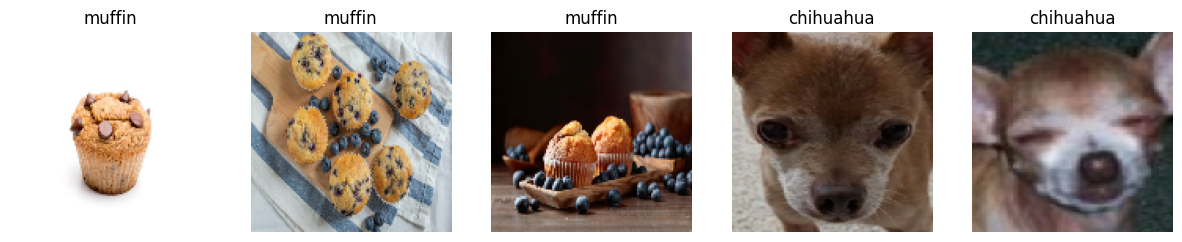

Epoch 1/10
 9/44 ━━━━━━━━━━━━━━━━━━━━ 9s 267ms/step - accuracy: 0.5468 - loss: 1017.8117

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 253ms/step - accuracy: 0.5893 - loss: 137.5364
Epoch 2/10
 2/44 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step - accuracy: 0.7734 - loss: 0.5668 

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 258ms/step - accuracy: 0.6921 - loss: 0.5532
Epoch 3/10
 5/44 ━━━━━━━━━━━━━━━━━━━━ 9s 245ms/step - accuracy: 0.7770 - loss: 0.4458

...

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 240ms/step - accuracy: 0.9886 - loss: 0.0486

Testing the model...


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Test Accuracy: 99.64%


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


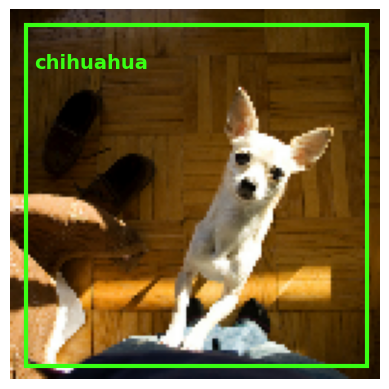

In [ ]:
import matplotlib.patches as patches

# Dataset available at: https://github.com/rcgc/chihuahua-muffin

ds_muffin_dog = tf.keras.utils.image_dataset_from_directory(
    "chihuahua-muffin",
    image_size=(128, 128),
    batch_size=32
)
class_names_md = ds_muffin_dog.class_names

plt.figure(figsize=(15, 5))
for images, labels in ds_muffin_dog.take(1):
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_md[labels[i]])
        plt.axis('off')
plt.show()

model_md = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(class_names_md), activation='softmax')
])

model_md.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_md.fit(ds_muffin_dog, epochs=10)

print("\nTesting the model...")
test_loss_md, test_acc_md = model_md.evaluate(ds_muffin_dog, verbose=0)
print(f"Test Accuracy: {test_acc_md * 100:.2f}%")

for images, labels in ds_muffin_dog.take(1):
    sample_img = images[0]
    prediction = model_md.predict(tf.expand_dims(sample_img, 0), verbose=0)
    predicted_class = class_names_md[tf.argmax(prediction[0]).numpy()]

    fig, ax = plt.subplots(1)
    ax.imshow(sample_img.numpy().astype("uint8"))
    rect = patches.Rectangle((5, 5), 118, 118, linewidth=3, edgecolor='#39FF14', facecolor='none')
    ax.add_patch(rect)
    plt.text(8, 20, predicted_class, color='#39FF14', fontsize=14, weight='bold')
    plt.axis('off')
    plt.show()
    break


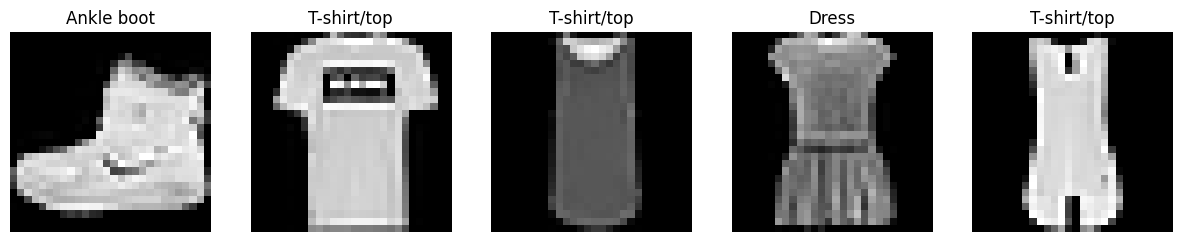

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8032 - loss: 0.5453
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8696 - loss: 0.3617
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8868 - loss: 0.3099
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8993 - loss: 0.2771
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9074 - loss: 0.2530
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9140 - loss: 0.2329
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9220 - loss: 0.2137
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9282 - loss: 0.1973
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9309 - loss: 0.1864
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9381 - loss: 0.1699

Testing the model...
Test Accuracy: 90.75%


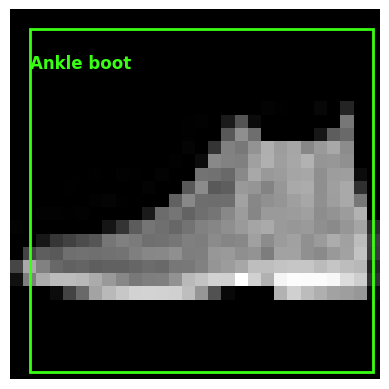

In [15]:
from keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
class_names_fm = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names_fm[y_train[i]])
    plt.axis('off')
plt.show()

x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

model_fm = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model_fm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_fm.fit(x_train, y_train, epochs=10, batch_size=128)

print("\nTesting the model...")
_, acc_fm = model_fm.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {acc_fm * 100:.2f}%")

sample_img_fm = x_test[0]
pred_fm = class_names_fm[tf.argmax(model_fm.predict(tf.expand_dims(sample_img_fm, 0), verbose=0)[0]).numpy()]

fig, ax = plt.subplots(1)
ax.imshow(sample_img_fm.squeeze(), cmap='gray')
ax.add_patch(patches.Rectangle((1, 1), 26, 26, linewidth=2, edgecolor='#39FF14', facecolor='none'))
plt.text(1, 4, pred_fm, color='#39FF14', fontsize=12, weight='bold')
plt.axis('off')
plt.show()


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /Users/zurekmartin/tensorflow_datasets/malaria/incomplete.ZBZ1VI_1.0.0/malaria-train.tfrecord*...:  …

Dataset malaria downloaded and prepared to /Users/zurekmartin/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


I0000 00:00:1776370211.163581  555349 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


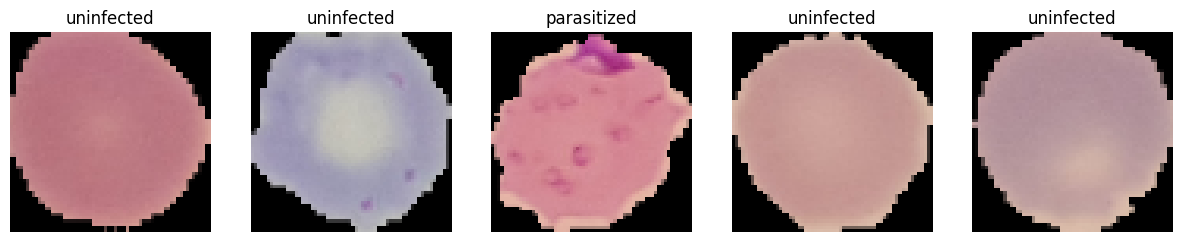

Epoch 1/5
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 125ms/step - accuracy: 0.7441 - loss: 0.5085
Epoch 2/5
345/345 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.9182 - loss: 0.2179
Epoch 3/5
345/345 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.9423 - loss: 0.1661
Epoch 4/5
345/345 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.9533 - loss: 0.1375
Epoch 5/5
345/345 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.9611 - loss: 0.1155

Testing the model...
Test Accuracy: 94.50%


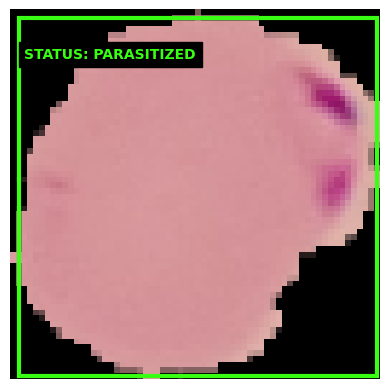

In [16]:
import tensorflow_datasets as tfds

ds, info = tfds.load('malaria', split='train', with_info=True, as_supervised=True)
class_names_malaria = info.features['label'].names

train_size = int(0.8 * info.splits['train'].num_examples)
ds_train = ds.take(train_size)
ds_test = ds.skip(train_size)

def preprocess(image, label):
    image = tf.image.resize(image, (64, 64))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = ds_train.map(preprocess).batch(64)
ds_test = ds_test.map(preprocess).batch(64)

plt.figure(figsize=(15, 5))
for images, labels in ds_train.take(1):
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i])
        plt.title(class_names_malaria[labels[i]])
        plt.axis('off')
plt.show()

model_malaria = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')
])

model_malaria.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_malaria.fit(ds_train, epochs=5)

print("\nTesting the model...")
_, acc_malaria = model_malaria.evaluate(ds_test, verbose=0)
print(f"Test Accuracy: {acc_malaria * 100:.2f}%")

for images, labels in ds_test.take(1):
    sample_img_mal = images[0]
    pred_mal = class_names_malaria[tf.argmax(model_malaria.predict(tf.expand_dims(sample_img_mal, 0), verbose=0)[0]).numpy()]

    fig, ax = plt.subplots(1)
    ax.imshow(sample_img_mal)
    ax.add_patch(patches.Rectangle((1, 1), 62, 62, linewidth=3, edgecolor='#39FF14', facecolor='none'))
    plt.text(2, 8, f"STATUS: {pred_mal.upper()}", color='#39FF14', fontsize=10, weight='bold', backgroundcolor='black')
    plt.axis('off')
    plt.show()
    break


# Commentary

While working on this assignment, I learned how to implement three different convolutional neural network projects, ranging from a funny chihuahua versus muffin classifier to clothing categorization and medical malaria detection. Now I understood the mathematical relationship between the applied convolutional filters, the extracted spatial features, and the final image prediction. I found out how the depth of the architecture and the chosen dataset directly dictate the behavior of the model and its ability to generalize across entirely different visual domains.

I chose these three specific topics to demonstrate the versatility of CNNs and to serve as user guidance. First, the Chihuahua versus Muffin classifier tackles a bizarre and visually confusing task. It tests the network's ability to distinguish between a small dog and a pastry based on subtle textures. Second, the Fashion MNIST project serves as a fundamental baseline to categorize various clothing items. It illustrates how a model learns to recognize basic shapes and edges of everyday apparel. Finally, the Malaria detection project addresses a critical real-world medical problem. It demonstrates how convolutional layers can accurately identify parasitized cells from uninfected ones in microscopic images.

At first, it was not clear why complex convolutional layers are necessary for seemingly absurd or visually confusing tasks instead of standard dense networks. It turned out that the hierarchical extraction of 2D spatial features is the absolute key to the success of CNNs, and without it, the model would indefinitely struggle to differentiate between these visually similar but distinct categories during training.
